# Iris Flower Classification
End-to-end exploratory analysis and classification using the supplied `Iris.csv` dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path('../data/Iris.csv')
df = pd.read_csv(DATA_PATH)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
df.info()
print(df.describe(include='all'))
print('Missing values:\n', df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
                Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
count   150.000000     150.000000    150.000000     150.000000    150.000000   
unique         NaN            NaN           NaN            NaN           NaN   
top            NaN            NaN           NaN            NaN           NaN   
freq           NaN            NaN           NaN            NaN           NaN   
mean     75.500000       5.843333      3.054000       3.758667      1.198667   
st

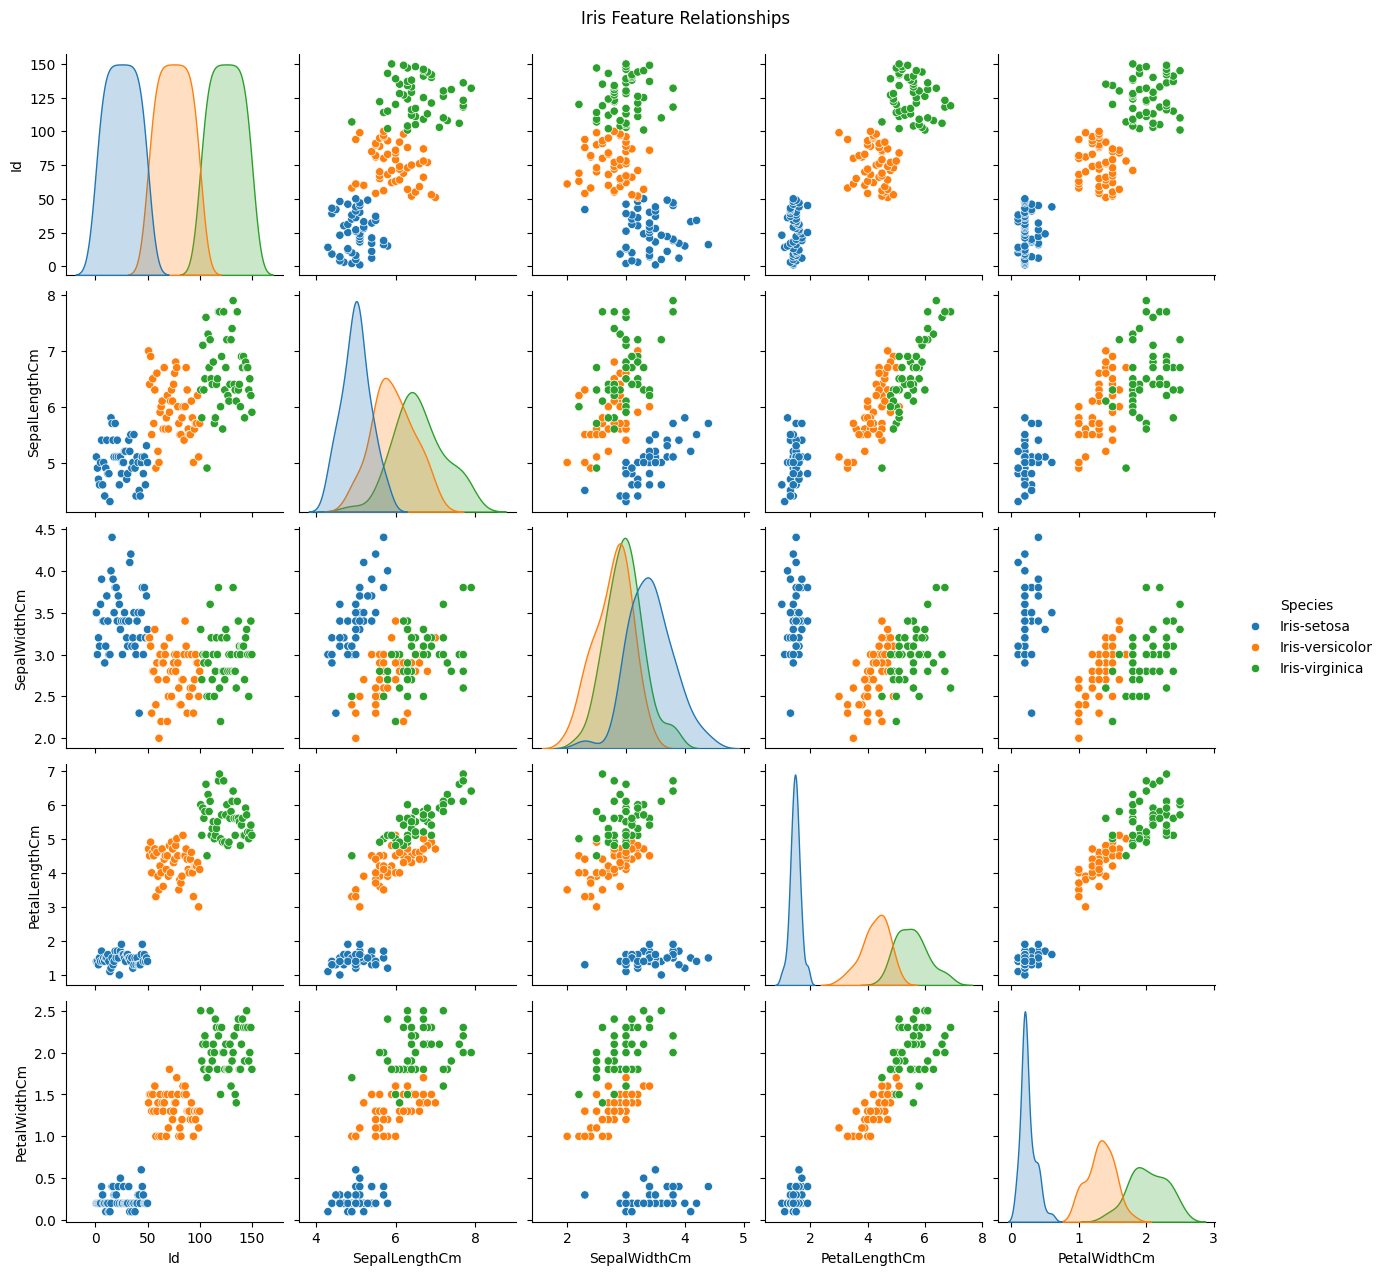

In [3]:
sns.pairplot(df, hue='Species')
plt.suptitle('Iris Feature Relationships', y=1.02)
plt.show()

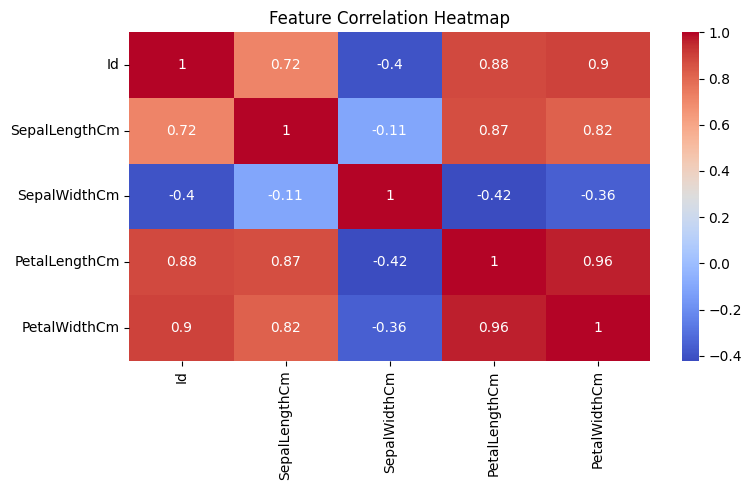

In [4]:
plt.figure(figsize=(8,5))
corr = df.drop(columns=['Species']).corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Modeling
The production training pipeline is implemented in `src/train.py` and compares Logistic Regression, KNN, Decision Tree, Random Forest, and SVM using stratified 5-fold cross-validation.

In [5]:
%cd ..
!python -m src.train

c:\Users\ELCOT\Desktop\iris_flower_classification_project


c:\Users\ELCOT\Desktop\iris_flower_classification_project\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]



Model comparison:
              model  cv_accuracy_mean  cv_accuracy_std  test_accuracy
                SVM          0.966667         0.016667       0.966667
Logistic Regression          0.958333         0.026352       0.933333
                KNN          0.958333         0.026352       0.933333
      Random Forest          0.950000         0.031180       0.900000
      Decision Tree          0.941667         0.020412       0.900000

Best model: SVM
Test metrics:
{
  "accuracy": 0.9666666666666667,
  "precision_weighted": 0.9696969696969696,
  "recall_weighted": 0.9666666666666667,
  "f1_weighted": 0.9665831244778613
}

Saved model to: C:\Users\ELCOT\Desktop\iris_flower_classification_project\models\iris_best_model.joblib


In [6]:
comparison = pd.read_csv('reports/model_comparison.csv')
comparison

,model,cv_accuracy_mean,cv_accuracy_std,test_accuracy
0,SVM,0.966667,0.016667,0.966667
1,Logistic Regression,0.958333,0.026352,0.933333
2,KNN,0.958333,0.026352,0.933333
3,Random Forest,0.950000,0.031180,0.900000
4,Decision Tree,0.941667,0.020412,0.900000
